# Classification of Life-Threatening Arrhythmia ECG Signals Using Deep Learning

**Kaggle Cloud Training Script for ECG Classification**

**Author:** Mohamad AlJasem  
**Website:** [https://aljasem.eu.org](https://aljasem.eu.org)  
**GitHub:** [https://github.com/m-aljasem/ecg-arrhythmia-classifier-AI](https://github.com/m-aljasem/ecg-arrhythmia-classifier-AI)  
**Live Demo:** [https://ecg-classifier.aljasem.eu.org](https://ecg-classifier.aljasem.eu.org)  
**Contact:** [mohamad@aljasem.eu.org](mailto:mohamad@aljasem.eu.org)

---

This script is designed to run directly in Kaggle without needing to download
or manage data locally. It handles the complete training pipeline.

## KAGGLE SETUP INSTRUCTIONS:
1. Create a new Kaggle notebook
2. Add the PTB-XL dataset as input data source:
   https://www.kaggle.com/datasets/khyeh0719/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1-0-1
3. Upload this script or copy-paste the code into the notebook
4. If using the project package, upload the entire 'src' folder to the notebook
5. Run the script

## Note: Kaggle paths:
- Input data: /kaggle/input/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1-0-1/
- Working directory: /kaggle/working/
- Model outputs will be saved to: /kaggle/working/models/
- Processed data will be saved to: /kaggle/working/data/

In [1]:
!pip install wfdb

In [2]:
import os
import sys
import ast
import math
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import sklearn.metrics

2026-03-02 23:35:25.538367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772494525.739699     126 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772494525.793402     126 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772494526.212235     126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772494526.212279     126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772494526.212282     126 computation_placer.cc:177] computation placer alr

In [15]:


# ============================================================================
# KAGGLE PATHS CONFIGURATION
# ============================================================================

KAGGLE_INPUT = '/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'
KAGGLE_WORKING = '/kaggle/working/'

# Ensure output directories exist
os.makedirs(os.path.join(KAGGLE_WORKING, 'models'), exist_ok=True)
os.makedirs(os.path.join(KAGGLE_WORKING, 'data'), exist_ok=True)

# Model paths
MODEL01_CHECKPOINT = os.path.join(KAGGLE_WORKING, 'models', 'model01.keras')
MODEL02_CHECKPOINT = os.path.join(KAGGLE_WORKING, 'models', 'model02.keras')
MODEL03_CHECKPOINT = os.path.join(KAGGLE_WORKING, 'models', 'model03.keras')
NUMPY_DATA_FILE = os.path.join(KAGGLE_WORKING, 'data', 'data.npz')

# Disable TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ============================================================================
# CONFIGURATION CONSTANTS
# ============================================================================

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
SAMPLING_RATE = 100
RANDOM_SEED = 42

# Model hyperparameters
MODEL_CONFIGS = {
    'model01': {
        'batch_size': 32,
        'epochs': 40,
        'patience': 10,
    },
    'model02': {
        'batch_size': 32,
        'epochs': 100,
        'patience': 20,
    },
    'model03': {
        'batch_size': 32,
        'epochs': 100,
        'patience': 20,
        'window_size': 800,
        'window_shift': -1,
        'sigma': 0.05,
    }
}

sns.set_style('darkgrid')

print("=" * 80)
print("ECG CLASSIFICATION - KAGGLE CLOUD TRAINING")
print("=" * 80)
print(f"Input Data Path: {KAGGLE_INPUT}")
print(f"Working Directory: {KAGGLE_WORKING}")
print(f"Random Seed: {RANDOM_SEED}")

ECG CLASSIFICATION - KAGGLE CLOUD TRAINING
Input Data Path: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
Working Directory: /kaggle/working/
Random Seed: 42


In [16]:


# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_data():
    """Load ECG metadata and raw signals from Kaggle input"""
    print("\n[1/5] Loading ECG Metadata...")
    
    ecg_df = pd.read_csv(
        os.path.join(KAGGLE_INPUT, 'ptbxl_database.csv'), 
        index_col='ecg_id'
    )
    ecg_df.scp_codes = ecg_df.scp_codes.apply(lambda x: ast.literal_eval(x))
    ecg_df.patient_id = ecg_df.patient_id.astype(int)
    ecg_df.nurse = ecg_df.nurse.astype('Int64')
    ecg_df.site = ecg_df.site.astype('Int64')
    ecg_df.validated_by = ecg_df.validated_by.astype('Int64')
    
    print(f"  ✓ Loaded {len(ecg_df)} ECG records")
    
    # Load SCP statements
    scp_df = pd.read_csv(
        os.path.join(KAGGLE_INPUT, 'scp_statements.csv'), 
        index_col=0
    )
    scp_df = scp_df[scp_df.diagnostic == 1]
    print(f"  ✓ Loaded {len(scp_df)} SCP diagnostic statements")
    
    return ecg_df, scp_df


def add_diagnostic_classes(ecg_df, scp_df):
    """Add diagnostic superclasses to ECG dataframe"""
    def diagnostic_class(scp):
        res = set()
        for k in scp.keys():
            if k in scp_df.index:
                res.add(scp_df.loc[k].diagnostic_class)
        return list(res)
    
    ecg_df['scp_classes'] = ecg_df.scp_codes.apply(diagnostic_class)
    print("  ✓ Added diagnostic classes to records")


def load_raw_data(ecg_df):
    """Load raw ECG signal data"""
    print("\n[2/5] Loading ECG Signals (this may take a few minutes)...")
    
    data = [wfdb.rdsamp(os.path.join(KAGGLE_INPUT, f)) 
           for f in ecg_df.filename_lr]
    ecg_data = np.array([signal for signal, meta in data])
    
    print(f"  ✓ Loaded {ecg_data.shape[0]} signals, shape: {ecg_data.shape}")
    return ecg_data



In [17]:

# ============================================================================
# DATA PREPROCESSING FUNCTIONS
# ============================================================================

def create_metadata_features(ecg_df):
    """Create features from patient metadata"""
    print("\n[3/5] Creating Features...")
    
    X = pd.DataFrame(index=ecg_df.index)
    
    X['age'] = ecg_df.age
    X['age'].fillna(0, inplace=True)
    
    X['sex'] = ecg_df.sex.astype(float)
    X['sex'].fillna(0, inplace=True)
    
    X['height'] = ecg_df.height
    X.loc[X['height'] < 50, 'height'] = np.nan
    X['height'].fillna(0, inplace=True)
    
    X['weight'] = ecg_df.weight
    X['weight'].fillna(0, inplace=True)
    
    X['infarction_stadium1'] = ecg_df.infarction_stadium1.replace({
        'unknown': 0, 'Stadium I': 1, 'Stadium I-II': 2,
        'Stadium II': 3, 'Stadium II-III': 4, 'Stadium III': 5
    }).fillna(0)
    
    X['infarction_stadium2'] = ecg_df.infarction_stadium2.replace({
        'unknown': 0, 'Stadium I': 1, 'Stadium II': 2, 'Stadium III': 3
    }).fillna(0)
    
    X['pacemaker'] = (ecg_df.pacemaker == 'ja, pacemaker').astype(float)
    
    print(f"  ✓ Created metadata features: {X.shape}")
    return X


def create_target_labels(ecg_df):
    """Create target labels from diagnostic classes"""
    Z = pd.DataFrame(0, index=ecg_df.index, columns=SUPERCLASSES, dtype='int')
    
    for i in Z.index:
        for k in ecg_df.loc[i].scp_classes:
            if k in Z.columns:
                Z.loc[i, k] = 1
    
    print(f"  ✓ Created target labels: {Z.shape}")
    print(f"    Class distribution: {dict(Z.sum(axis=0))}")
    return Z


def split_data(ecg_df, X, ecg_data, Z):
    """Split data into train/valid/test sets"""
    train_mask = ecg_df.strat_fold <= 8
    valid_mask = ecg_df.strat_fold == 9
    test_mask = ecg_df.strat_fold == 10
    
    X_train, X_valid, X_test = X[train_mask], X[valid_mask], X[test_mask]
    
    Y_train = ecg_data[np.array(X_train.index) - 1]
    Y_valid = ecg_data[np.array(X_valid.index) - 1]
    Y_test = ecg_data[np.array(X_test.index) - 1]
    
    Z_train, Z_valid, Z_test = Z[train_mask], Z[valid_mask], Z[test_mask]
    
    print("  ✓ Data split:")
    print(f"    Train: {X_train.shape[0]} samples")
    print(f"    Valid: {X_valid.shape[0]} samples")
    print(f"    Test:  {X_test.shape[0]} samples")
    
    return (X_train, X_valid, X_test), (Y_train, Y_valid, Y_test), \
           (Z_train, Z_valid, Z_test)


def standardize_data(X_train, X_valid, X_test, Y_train, Y_valid, Y_test):
    """Standardize input data"""
    # Standardize metadata
    x_scaler = StandardScaler()
    x_scaler.fit(X_train)
    
    X_train_std = pd.DataFrame(x_scaler.transform(X_train), columns=X_train.columns)
    X_valid_std = pd.DataFrame(x_scaler.transform(X_valid), columns=X_valid.columns)
    X_test_std = pd.DataFrame(x_scaler.transform(X_test), columns=X_test.columns)
    
    # Standardize ECG signals
    y_scaler = StandardScaler()
    y_scaler.fit(Y_train.reshape(-1, Y_train.shape[-1]))
    
    Y_train_std = y_scaler.transform(Y_train.reshape(-1, Y_train.shape[-1])).reshape(Y_train.shape)
    Y_valid_std = y_scaler.transform(Y_valid.reshape(-1, Y_valid.shape[-1])).reshape(Y_valid.shape)
    Y_test_std = y_scaler.transform(Y_test.reshape(-1, Y_test.shape[-1])).reshape(Y_test.shape)
    
    print("  ✓ Data standardized")
    return (X_train_std, X_valid_std, X_test_std), (Y_train_std, Y_valid_std, Y_test_std)


def save_data(X_train, X_valid, X_test, Y_train, Y_valid, Y_test, 
             Z_train, Z_valid, Z_test):
    """Save preprocessed data to NPZ file"""
    save_args = {
        'X_train': X_train.to_numpy().astype('float32') if isinstance(X_train, pd.DataFrame) else X_train.astype('float32'),
        'X_valid': X_valid.to_numpy().astype('float32') if isinstance(X_valid, pd.DataFrame) else X_valid.astype('float32'),
        'X_test': X_test.to_numpy().astype('float32') if isinstance(X_test, pd.DataFrame) else X_test.astype('float32'),
        'Y_train': Y_train.astype('float32'),
        'Y_valid': Y_valid.astype('float32'),
        'Y_test': Y_test.astype('float32'),
        'Z_train': Z_train.to_numpy().astype('float32') if isinstance(Z_train, pd.DataFrame) else Z_train.astype('float32'),
        'Z_valid': Z_valid.to_numpy().astype('float32') if isinstance(Z_valid, pd.DataFrame) else Z_valid.astype('float32'),
        'Z_test': Z_test.to_numpy().astype('float32') if isinstance(Z_test, pd.DataFrame) else Z_test.astype('float32'),
    }
    np.savez(NUMPY_DATA_FILE, **save_args)
    print(f"  ✓ Data saved to {NUMPY_DATA_FILE}")



In [18]:

# ============================================================================
# MODEL DEFINITION FUNCTIONS
# ============================================================================

def create_X_model(X_input, units=32, dropouts=0.3):
    """Create metadata processing model"""
    X = keras.layers.Dense(units, activation='relu', name='X_dense_1')(X_input)
    X = keras.layers.Dropout(dropouts, name='X_drop_1')(X)
    X = keras.layers.Dense(units, activation='relu', name='X_dense_2')(X)
    X = keras.layers.Dropout(dropouts, name='X_drop_2')(X)
    return X


def create_Y_model(Y_input, filters=(32, 64, 128), kernel_size=(5, 3, 3), strides=(1, 1, 1)):
    """Create 1D CNN model for ECG signals"""
    f1, f2, f3 = filters
    k1, k2, k3 = kernel_size
    s1, s2, s3 = strides
    
    X = keras.layers.Conv1D(f1, k1, strides=s1, padding='same', name='Y_conv_1')(Y_input)
    X = keras.layers.BatchNormalization(name='Y_norm_1')(X)
    X = keras.layers.ReLU(name='Y_relu_1')(X)
    X = keras.layers.MaxPool1D(2, name='Y_pool_1')(X)
    
    X = keras.layers.Conv1D(f2, k2, strides=s2, padding='same', name='Y_conv_2')(X)
    X = keras.layers.BatchNormalization(name='Y_norm_2')(X)
    X = keras.layers.ReLU(name='Y_relu_2')(X)
    X = keras.layers.MaxPool1D(2, name='Y_pool_2')(X)
    
    X = keras.layers.Conv1D(f3, k3, strides=s3, padding='same', name='Y_conv_3')(X)
    X = keras.layers.BatchNormalization(name='Y_norm_3')(X)
    X = keras.layers.ReLU(name='Y_relu_3')(X)
    
    X = keras.layers.GlobalAveragePooling1D(name='Y_aver')(X)
    X = keras.layers.Dropout(0.5, name='Y_drop')(X)
    
    return X


def create_model01(X_shape, Z_shape):
    """Create metadata-only classifier"""
    X_inputs = keras.Input(X_shape[1:], name='X_inputs')
    
    X = create_X_model(X_inputs)
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_1')(X)
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_2')(X)
    X = keras.layers.Dropout(0.5, name='Z_drop_1')(X)
    outputs = keras.layers.Dense(Z_shape[-1], activation='sigmoid', name='Z_outputs')(X)
    
    model = keras.Model(inputs=X_inputs, outputs=outputs, name='model01')
    return model


def create_model02(X_shape, Y_shape, Z_shape):
    """Create combined metadata and ECG signal classifier"""
    X_inputs = keras.Input(X_shape[1:], name='X_inputs')
    Y_inputs = keras.Input(Y_shape[1:], name='Y_inputs')
    
    X = keras.layers.Concatenate(name='Z_concat')([
        create_X_model(X_inputs),
        create_Y_model(Y_inputs, filters=(64, 128, 256), kernel_size=(7, 3, 3))
    ])
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_1')(X)
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_2')(X)
    X = keras.layers.Dropout(0.5, name='Z_drop_1')(X)
    outputs = keras.layers.Dense(Z_shape[-1], activation='sigmoid', name='Z_outputs')(X)
    
    model = keras.Model(inputs=[X_inputs, Y_inputs], outputs=outputs, name='model02')
    return model



In [22]:

# ============================================================================
# DATA AUGMENTATION FUNCTIONS
# ============================================================================

def sliding_window(x, size, shift):
    """Apply sliding window to ECG signal"""
    if 0 < size < x.shape[0]:
        shift = np.random.randint(0, x.shape[0] - size) if shift < 0 else shift
        return x[shift:size + shift, :]
    else:
        return x


class AugmentedDataGenerator(keras.utils.Sequence):
    """Generate augmented ECG data with sliding window and noise"""
    
    def __init__(self, x, y, z, batch_size=32, window_size=0, 
                 window_shift=0, sigma=0.0, **kwargs):
        super(AugmentedDataGenerator, self).__init__(**kwargs)
        self.x = x
        self.y = y
        self.z = z
        self.batch_size = batch_size
        self.window_size = window_size
        self.window_shift = window_shift
        self.sigma = sigma
    
    @property
    def x_shape(self):
        return (self.batch_size,) + self.x.shape[1:]
    
    @property
    def y_shape(self):
        y_len = self.window_size if self.window_size > 0 else self.y.shape[1]
        return (self.batch_size, y_len) + self.y.shape[2:]
    
    @property
    def z_shape(self):
        return (self.batch_size,) + self.z.shape[1:]
    
    def __len__(self):
        return math.ceil(len(self.y) / self.batch_size)
    
    def __getitem__(self, idx):
        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = np.array([
            sliding_window(r, self.window_size, self.window_shift) 
            for r in self.y[idx * self.batch_size:(idx + 1) * self.batch_size]
        ])
        batch_z = self.z[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        # Convert pandas DataFrames to numpy arrays if needed
        if isinstance(batch_x, pd.DataFrame):
            batch_x = batch_x.to_numpy()
        if isinstance(batch_z, pd.DataFrame):
            batch_z = batch_z.to_numpy()
        
        if self.sigma > 0:
            batch_y += np.random.normal(loc=0.0, scale=self.sigma, size=batch_y.shape)
        
        return (batch_x, batch_y), batch_z


In [25]:


# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

def train_model01(X_train, X_valid, X_test, Z_train, Z_valid, Z_test):
    """Train metadata-only model"""
    print("\n" + "=" * 80)
    print("TRAINING MODEL01 (Metadata Only)")
    print("=" * 80)
    
    config = MODEL_CONFIGS['model01']
    
    # Create and compile model
    model = create_model01(X_train.shape, Z_train.shape)
    model.compile(optimizer='adam', loss='binary_crossentropy', 
                 metrics=['binary_accuracy', 'Precision', 'Recall'])
    print(model.summary())
    
    # Setup callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_binary_accuracy',
                                     patience=config['patience']),
        keras.callbacks.ModelCheckpoint(filepath=MODEL01_CHECKPOINT,
                                       monitor='val_binary_accuracy',
                                       save_best_only=True)
    ]
    
    # Train model
    history = model.fit(X_train, Z_train, epochs=config['epochs'],
                       batch_size=config['batch_size'], callbacks=callbacks,
                       validation_data=(X_valid, Z_valid), verbose=1)
    
    # Evaluate
    model = keras.models.load_model(MODEL01_CHECKPOINT)
    results = model.evaluate(X_test, Z_test)
    print(f"\n✓ Model01 Test Results: Loss={results[0]:.4f}, Accuracy={results[1]:.4f}")
    
    return model, history


def train_model02(X_train, X_valid, X_test, Y_train, Y_valid, Y_test, 
                 Z_train, Z_valid, Z_test):
    """Train combined metadata and ECG model"""
    print("\n" + "=" * 80)
    print("TRAINING MODEL02 (Combined Metadata + ECG)")
    print("=" * 80)
    
    config = MODEL_CONFIGS['model02']
    
    # Create and compile model
    model = create_model02(X_train.shape, Y_train.shape, Z_train.shape)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['binary_accuracy', 'Precision', 'Recall'])
    print(model.summary())
    
    # Setup callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_binary_accuracy',
                                     patience=config['patience']),
        keras.callbacks.ModelCheckpoint(filepath=MODEL02_CHECKPOINT,
                                       monitor='val_binary_accuracy',
                                       save_best_only=True)
    ]
    
    # Train model
    history = model.fit([X_train, Y_train], Z_train,
                       epochs=config['epochs'],
                       batch_size=config['batch_size'],
                       callbacks=callbacks,
                       validation_data=([X_valid, Y_valid], Z_valid), verbose=1)
    
    # Evaluate
    model = keras.models.load_model(MODEL02_CHECKPOINT)
    results = model.evaluate([X_test, Y_test], Z_test)
    print(f"\n✓ Model02 Test Results: Loss={results[0]:.4f}, Accuracy={results[1]:.4f}")
    
    return model, history


def train_model03_with_augmentation(X_train, X_valid, X_test, Y_train, Y_valid, Y_test,
                                   Z_train, Z_valid, Z_test):
    """Train model with data augmentation"""
    print("\n" + "=" * 80)
    print("TRAINING MODEL03 (With Data Augmentation)")
    print("=" * 80)
    
    config = MODEL_CONFIGS['model03']
    
    # Create generators
    train_gen = AugmentedDataGenerator(X_train, Y_train, Z_train,
                                      window_size=config['window_size'],
                                      window_shift=config['window_shift'],
                                      sigma=config['sigma'])
    valid_gen = AugmentedDataGenerator(X_valid, Y_valid, Z_valid,
                                      window_size=config['window_size'])
    test_gen = AugmentedDataGenerator(X_test, Y_test, Z_test,
                                     window_size=config['window_size'])
    
    # Create and compile model
    model = create_model02(train_gen.x_shape, train_gen.y_shape, train_gen.z_shape)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['binary_accuracy', 'Precision', 'Recall'])
    print(model.summary())
    
    # Setup callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_binary_accuracy',
                                     patience=config['patience']),
        keras.callbacks.ModelCheckpoint(filepath=MODEL03_CHECKPOINT,
                                       monitor='val_binary_accuracy',
                                       save_best_only=True)
    ]
    
    # Train model
    history = model.fit(train_gen, epochs=config['epochs'],
                       callbacks=callbacks, validation_data=valid_gen, verbose=1)
    
    # Evaluate
    model = keras.models.load_model(MODEL03_CHECKPOINT)
    results = model.evaluate(test_gen)
    print(f"\n✓ Model03 Test Results: Loss={results[0]:.4f}, Accuracy={results[1]:.4f}")
    
    return model, history


In [26]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main training pipeline"""
    
    # Step 1: Load data
    print("\n" + "=" * 80)
    print("DATA LOADING & PREPROCESSING")
    print("=" * 80)
    
    ecg_df, scp_df = load_data()
    add_diagnostic_classes(ecg_df, scp_df)
    ecg_data = load_raw_data(ecg_df)
    
    # Step 2: Preprocess data
    X = create_metadata_features(ecg_df)
    Z = create_target_labels(ecg_df)
    
    (X_train, X_valid, X_test), (Y_train, Y_valid, Y_test), \
    (Z_train, Z_valid, Z_test) = split_data(ecg_df, X, ecg_data, Z)
    
    (X_train, X_valid, X_test), (Y_train, Y_valid, Y_test) = \
        standardize_data(X_train, X_valid, X_test, Y_train, Y_valid, Y_test)
    
    # Save processed data
    save_data(X_train, X_valid, X_test, Y_train, Y_valid, Y_test,
             Z_train, Z_valid, Z_test)
    
    # Step 3: Train models
    model01, history01 = train_model01(X_train, X_valid, X_test, 
                                       Z_train, Z_valid, Z_test)
    
    model02, history02 = train_model02(X_train, X_valid, X_test, Y_train, Y_valid, Y_test,
                                       Z_train, Z_valid, Z_test)
    
    model03, history03 = train_model03_with_augmentation(X_train, X_valid, X_test,
                                                         Y_train, Y_valid, Y_test,
                                                         Z_train, Z_valid, Z_test)
    
    # Step 4: Summary
    print("\n" + "=" * 80)
    print("TRAINING COMPLETE!")
    print("=" * 80)
    print(f"\n✓ All models trained successfully!")
    print(f"\nModel Checkpoints:")
    print(f"  - Model01: {MODEL01_CHECKPOINT}")
    print(f"  - Model02: {MODEL02_CHECKPOINT}")
    print(f"  - Model03: {MODEL03_CHECKPOINT}")
    print(f"\nProcessed Data:")
    print(f"  - NPZ File: {NUMPY_DATA_FILE}")
    print(f"\nAll outputs saved to: {KAGGLE_WORKING}")
    print("\nYou can now download the models and data from Kaggle output!")
    print("=" * 80)


if __name__ == '__main__':
    main()



DATA LOADING & PREPROCESSING

[1/5] Loading ECG Metadata...
  ✓ Loaded 21837 ECG records
  ✓ Loaded 44 SCP diagnostic statements
  ✓ Added diagnostic classes to records

[2/5] Loading ECG Signals (this may take a few minutes)...
  ✓ Loaded 21837 signals, shape: (21837, 1000, 12)

[3/5] Creating Features...
  ✓ Created metadata features: (21837, 7)


/tmp/ipykernel_126/3839000700.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age'].fillna(0, inplace=True)
/tmp/ipykernel_126/3839000700.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method

  ✓ Created target labels: (21837, 5)
    Class distribution: {'NORM': np.int64(9528), 'MI': np.int64(5486), 'STTC': np.int64(5250), 'CD': np.int64(4907), 'HYP': np.int64(2655)}
  ✓ Data split:
    Train: 17441 samples
    Valid: 2193 samples
    Test:  2203 samples
  ✓ Data standardized
  ✓ Data saved to /kaggle/working/data/data.npz

TRAINING MODEL01 (Metadata Only)


Model: "model01"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ X_inputs (InputLayer)           │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ X_dense_1 (Dense)               │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ X_drop_1 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ X_dense_2 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ X_drop_2 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Z_dense_1 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Z_dense_2 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Z_drop_1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Z_outputs (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Y_inputs            │ (None, 800, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_conv_1 (Conv1D)   │ (None, 800, 64)   │      5,440 │ Y_inputs[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_norm_1            │ (None, 800, 64)   │        256 │ Y_conv_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_relu_1 (ReLU)     │ (None, 800, 64)   │          0 │ Y_norm_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_pool_1            │ (None, 400, 64)   │          0 │ Y_relu_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_conv_2 (Conv1D)   │ (None, 400, 128)  │     24,704 │ Y_pool_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_norm_2            │ (None, 400, 128)  │        512 │ Y_conv_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_relu_2 (ReLU)     │ (None, 400, 128)  │          0 │ Y_norm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_pool_2            │ (None, 200, 128)  │          0 │ Y_relu_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_inputs            │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_conv_3 (Conv1D)   │ (None, 200, 256)  │     98,560 │ Y_pool_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_dense_1 (Dense)   │ (None, 32)        │        256 │ X_inputs[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_norm_3            │ (None, 200, 256)  │      1,024 │ Y_conv_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_drop_1 (Dropout)  │ (None, 32)        │          0 │ X_dense_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_relu_3 (ReLU)     │ (None, 200, 256)  │          0 │ Y_norm_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_dense_2 (Dense)   │ (None, 32)        │      1,056 │ X_drop_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_aver              │ (None, 256)       │          0 │ Y_relu_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_drop_2 (Dropout)  │ (None, 32)        │          0 │ X_dense_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Y_drop (Dropout)    │ (None, 256)       │          0 │ Y_aver[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Z_concat            │ (None, 288)       │          0 │ X_drop_2[0][0],   │
│ (Concatenate)       │                   │            │ Y_drop[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 154,789 (604.64 KB)

 Trainable params: 153,893 (601.14 KB)

 Non-trainable params: 896 (3.50 KB)

None
Epoch 1/100
546/546 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - Precision: 0.6222 - Recall: 0.4257 - binary_accuracy: 0.7876 - loss: 0.4643 - val_Precision: 0.7570 - val_Recall: 0.6058 - val_binary_accuracy: 0.8495 - val_loss: 0.3554
Epoch 2/100
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - Precision: 0.7597 - Recall: 0.6176 - binary_accuracy: 0.8536 - loss: 0.3548 - val_Precision: 0.7820 - val_Recall: 0.6718 - val_binary_accuracy: 0.8682 - val_loss: 0.3198
Epoch 3/100
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - Precision: 0.7868 - Recall: 0.6588 - binary_accuracy: 0.8683 - loss: 0.3274 - val_Precision: 0.7884 - val_Recall: 0.6900 - val_binary_accuracy: 0.8734 - val_loss: 0.3072
Epoch 4/100
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - Precision: 0.7944 - Recall: 0.6620 - binary_accuracy: 0.8702 - loss: 0.3206 - val_Precision: 0.7702 - val_Recall: 0.6839 - val_binary_accuracy: 0.8670 - val_loss: 0.3214
Epoch 5/100
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - Precision: 0.7971 - Recall: 0.6753

In [31]:
# ============================================================================
# SAVE SCALERS FOR PRODUCTION USE
# ============================================================================

import pickle

# The scalers are created in the standardize_data function, but we need to save them
# Let's recreate and save them from the loaded data

print("\n" + "=" * 80)
print("SAVING SCALERS FOR PRODUCTION USE")
print("=" * 80)

# Load the data
data = np.load(NUMPY_DATA_FILE)
X_train = data['X_train']
Y_train = data['Y_train']

# Recreate the scalers
x_scaler = StandardScaler()
x_scaler.fit(X_train)

y_scaler = StandardScaler()
y_scaler.fit(Y_train.reshape(-1, Y_train.shape[-1]))

# Save the scalers
scaler_file = os.path.join(KAGGLE_WORKING, 'scalers.pkl')
with open(scaler_file, 'wb') as f:
    pickle.dump({
        'x_scaler': x_scaler,
        'y_scaler': y_scaler,
        'superclasses': SUPERCLASSES,
        'feature_names': ['age', 'sex', 'height', 'weight', 'infarction_stadium1', 'infarction_stadium2', 'pacemaker']
    }, f)

print(f"\n✓ Scalers saved to: {scaler_file}")
print("\nFor your Streamlit app, download these files:")
print("=" * 80)
print("1. model03.keras         - Best performing model")
print("2. scalers.pkl           - Data preprocessing scalers (REQUIRED)")
print("3. data.npz              - (Optional) Sample test data for demo")
print("=" * 80)
print("\nIn your Streamlit app:")
print("  - Load model: keras.models.load_model('model03.keras')")
print("  - Load scalers: pickle.load(open('scalers.pkl', 'rb'))")
print("  - Use x_scaler to normalize metadata features")
print("  - Use y_scaler to normalize ECG signals")
print("=" * 80)



SAVING SCALERS FOR PRODUCTION USE

✓ Scalers saved to: /kaggle/working/scalers.pkl

For your Streamlit app, download these files:
1. model03.keras         - Best performing model
2. scalers.pkl           - Data preprocessing scalers (REQUIRED)
3. data.npz              - (Optional) Sample test data for demo

In your Streamlit app:
  - Load model: keras.models.load_model('model03.keras')
  - Load scalers: pickle.load(open('scalers.pkl', 'rb'))
  - Use x_scaler to normalize metadata features
  - Use y_scaler to normalize ECG signals


# Model Evaluation & Comparison

This section provides detailed performance metrics and visualizations to compare the three trained models:
- **Model01**: Metadata-only classifier
- **Model02**: Combined metadata + ECG signals
- **Model03**: Combined with data augmentation

We'll evaluate using multiple metrics including:
- AUC-ROC (Area Under the Curve - Receiver Operating Characteristic)
- F1 Score
- Precision
- Recall
- Accuracy


In [27]:
# ============================================================================
# EVALUATION & METRICS CALCULATION
# ============================================================================

def calculate_metrics(model, X_test, Y_test, Z_test, model_name, use_generator=False):
    """Calculate comprehensive metrics for a model"""
    from sklearn.metrics import (
        roc_auc_score, f1_score, precision_score, recall_score, 
        accuracy_score, classification_report
    )
    
    # Get predictions
    if use_generator:
        # For model03 with data augmentation
        test_gen = AugmentedDataGenerator(X_test, Y_test, Z_test, 
                                         window_size=MODEL_CONFIGS['model03']['window_size'])
        y_pred = model.predict(test_gen)
        y_true = Z_test.to_numpy() if isinstance(Z_test, pd.DataFrame) else Z_test
    elif Y_test is not None:
        # For model02 (combined)
        y_pred = model.predict([X_test, Y_test])
        y_true = Z_test.to_numpy() if isinstance(Z_test, pd.DataFrame) else Z_test
    else:
        # For model01 (metadata only)
        y_pred = model.predict(X_test)
        y_true = Z_test.to_numpy() if isinstance(Z_test, pd.DataFrame) else Z_test
    
    # Binarize predictions
    y_pred_binary = (y_pred >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred_binary),
        'Precision (Macro)': precision_score(y_true, y_pred_binary, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true, y_pred_binary, average='macro', zero_division=0),
        'F1 Score (Macro)': f1_score(y_true, y_pred_binary, average='macro', zero_division=0),
        'Precision (Micro)': precision_score(y_true, y_pred_binary, average='micro', zero_division=0),
        'Recall (Micro)': recall_score(y_true, y_pred_binary, average='micro', zero_division=0),
        'F1 Score (Micro)': f1_score(y_true, y_pred_binary, average='micro', zero_division=0),
    }
    
    # Calculate AUC-ROC for each class
    try:
        auc_scores = []
        for i in range(y_true.shape[1]):
            auc = roc_auc_score(y_true[:, i], y_pred[:, i])
            auc_scores.append(auc)
        metrics['AUC-ROC (Macro)'] = np.mean(auc_scores)
    except:
        metrics['AUC-ROC (Macro)'] = 0.0
    
    # Per-class metrics
    class_metrics = {}
    for i, class_name in enumerate(SUPERCLASSES):
        class_metrics[class_name] = {
            'precision': precision_score(y_true[:, i], y_pred_binary[:, i], zero_division=0),
            'recall': recall_score(y_true[:, i], y_pred_binary[:, i], zero_division=0),
            'f1': f1_score(y_true[:, i], y_pred_binary[:, i], zero_division=0),
            'auc': auc_scores[i] if len(auc_scores) > i else 0.0
        }
    
    return metrics, class_metrics, y_true, y_pred


# Calculate metrics for all models
print("\n" + "=" * 80)
print("CALCULATING METRICS FOR ALL MODELS")
print("=" * 80)

# Load the best models
model01 = keras.models.load_model(MODEL01_CHECKPOINT)
model02 = keras.models.load_model(MODEL02_CHECKPOINT)
model03 = keras.models.load_model(MODEL03_CHECKPOINT)

# Load test data (assuming it was saved in the main function)
data = np.load(NUMPY_DATA_FILE)
X_test = data['X_test']
Y_test = data['Y_test']
Z_test = data['Z_test']

# Calculate metrics for each model
print("\n[1/3] Evaluating Model01 (Metadata Only)...")
metrics_m1, class_metrics_m1, y_true_m1, y_pred_m1 = calculate_metrics(
    model01, X_test, None, Z_test, 'Model01', use_generator=False
)

print("[2/3] Evaluating Model02 (Combined Metadata + ECG)...")
metrics_m2, class_metrics_m2, y_true_m2, y_pred_m2 = calculate_metrics(
    model02, X_test, Y_test, Z_test, 'Model02', use_generator=False
)

print("[3/3] Evaluating Model03 (With Data Augmentation)...")
metrics_m3, class_metrics_m3, y_true_m3, y_pred_m3 = calculate_metrics(
    model03, X_test, Y_test, Z_test, 'Model03', use_generator=True
)

print("\n✓ Metrics calculation complete!")



CALCULATING METRICS FOR ALL MODELS

[1/3] Evaluating Model01 (Metadata Only)...
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[2/3] Evaluating Model02 (Combined Metadata + ECG)...
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
[3/3] Evaluating Model03 (With Data Augmentation)...
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

✓ Metrics calculation complete!


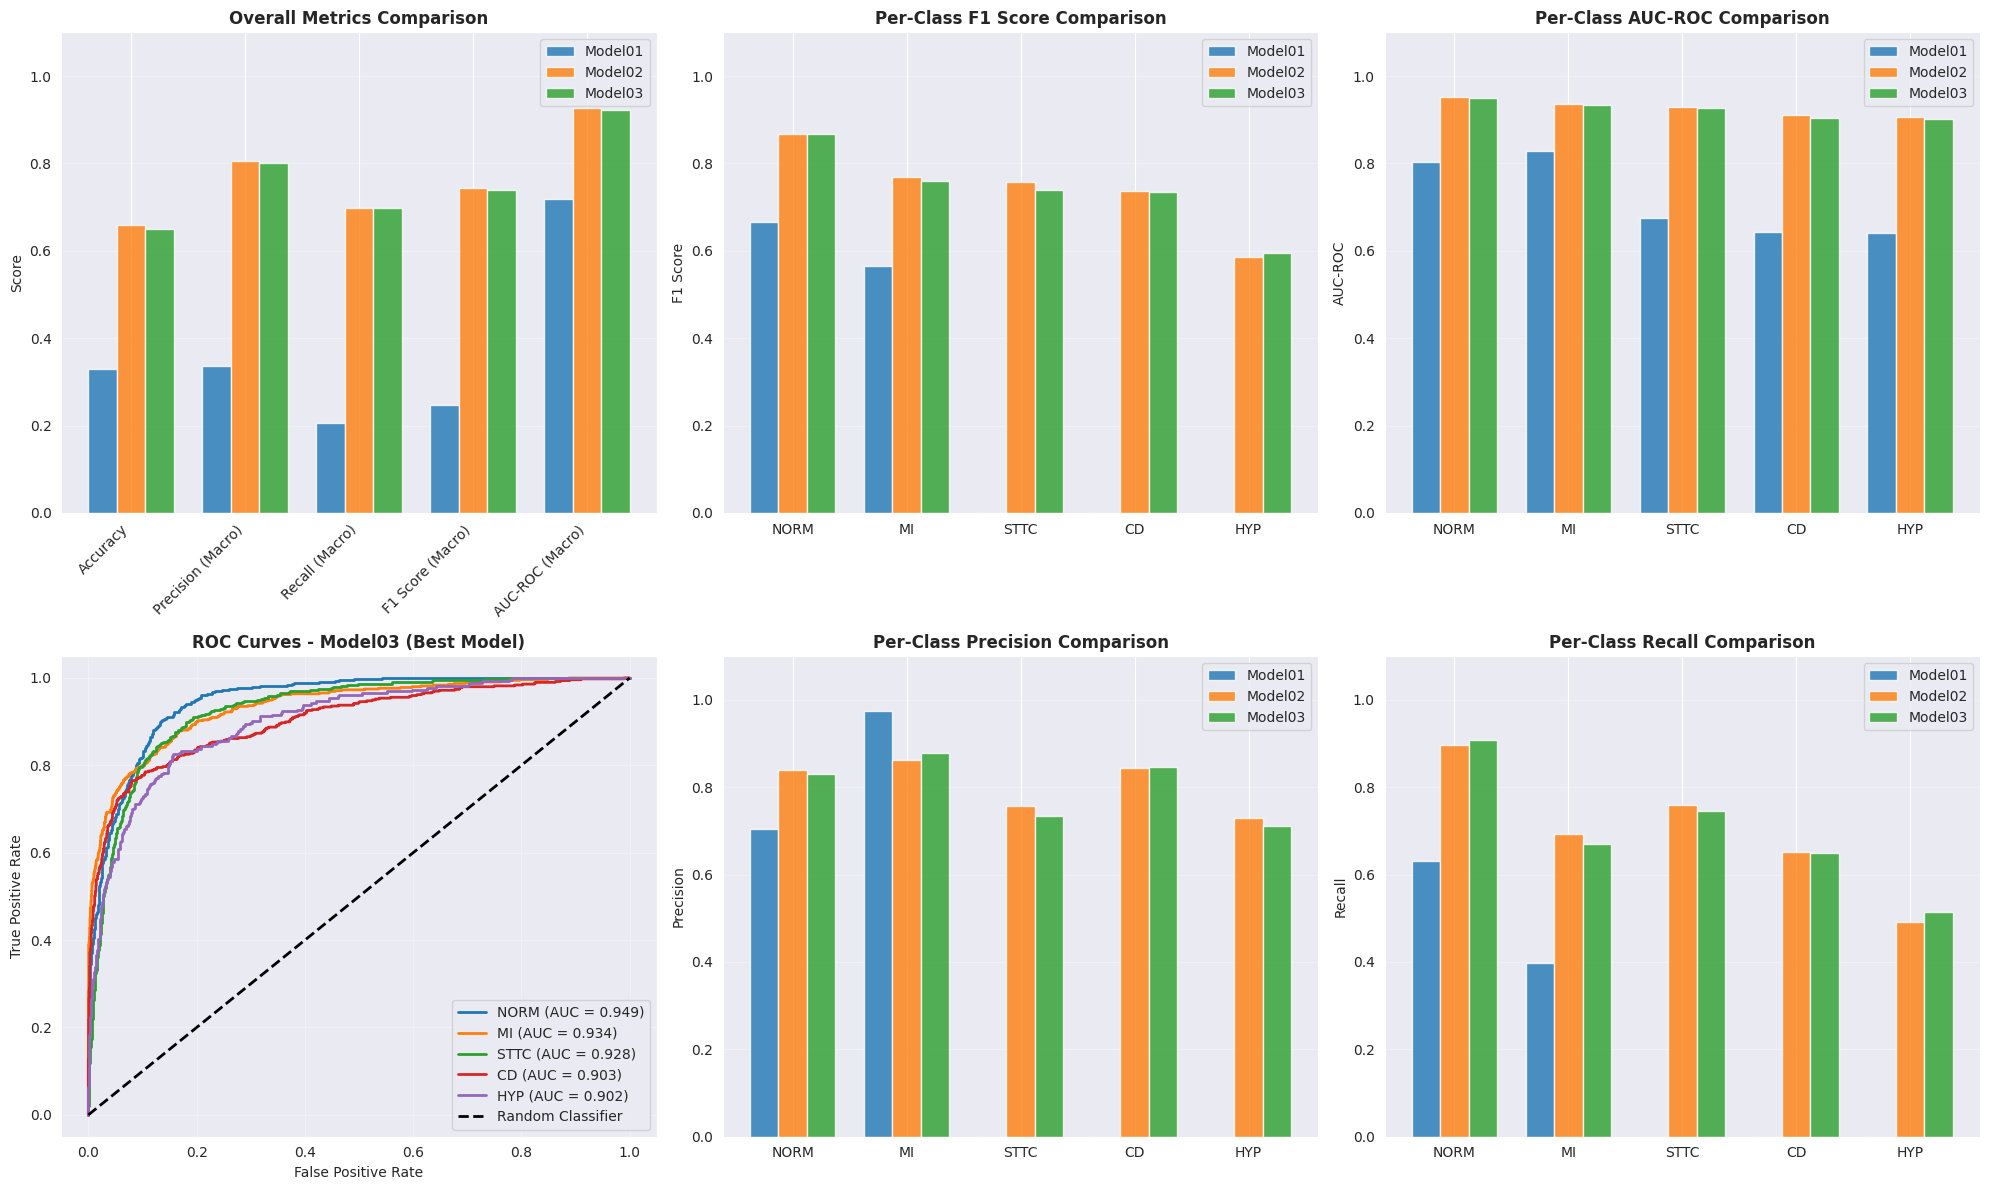


✓ Visualization saved to: /kaggle/working/models_comparison.png


In [28]:
# ============================================================================
# PERFORMANCE COMPARISON VISUALIZATIONS
# ============================================================================

from sklearn.metrics import roc_curve, auc, confusion_matrix

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))

# 1. Overall Metrics Comparison (Bar Chart)
ax1 = plt.subplot(2, 3, 1)
metrics_names = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)', 'AUC-ROC (Macro)']
model_names = ['Model01', 'Model02', 'Model03']
x = np.arange(len(metrics_names))
width = 0.25

values_m1 = [metrics_m1[m] for m in metrics_names]
values_m2 = [metrics_m2[m] for m in metrics_names]
values_m3 = [metrics_m3[m] for m in metrics_names]

ax1.bar(x - width, values_m1, width, label='Model01', alpha=0.8)
ax1.bar(x, values_m2, width, label='Model02', alpha=0.8)
ax1.bar(x + width, values_m3, width, label='Model03', alpha=0.8)

ax1.set_ylabel('Score')
ax1.set_title('Overall Metrics Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# 2. Per-Class F1 Score Comparison
ax2 = plt.subplot(2, 3, 2)
x_classes = np.arange(len(SUPERCLASSES))
f1_m1 = [class_metrics_m1[c]['f1'] for c in SUPERCLASSES]
f1_m2 = [class_metrics_m2[c]['f1'] for c in SUPERCLASSES]
f1_m3 = [class_metrics_m3[c]['f1'] for c in SUPERCLASSES]

ax2.bar(x_classes - width, f1_m1, width, label='Model01', alpha=0.8)
ax2.bar(x_classes, f1_m2, width, label='Model02', alpha=0.8)
ax2.bar(x_classes + width, f1_m3, width, label='Model03', alpha=0.8)

ax2.set_ylabel('F1 Score')
ax2.set_title('Per-Class F1 Score Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x_classes)
ax2.set_xticklabels(SUPERCLASSES)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.1])

# 3. Per-Class AUC-ROC Comparison
ax3 = plt.subplot(2, 3, 3)
auc_m1 = [class_metrics_m1[c]['auc'] for c in SUPERCLASSES]
auc_m2 = [class_metrics_m2[c]['auc'] for c in SUPERCLASSES]
auc_m3 = [class_metrics_m3[c]['auc'] for c in SUPERCLASSES]

ax3.bar(x_classes - width, auc_m1, width, label='Model01', alpha=0.8)
ax3.bar(x_classes, auc_m2, width, label='Model02', alpha=0.8)
ax3.bar(x_classes + width, auc_m3, width, label='Model03', alpha=0.8)

ax3.set_ylabel('AUC-ROC')
ax3.set_title('Per-Class AUC-ROC Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x_classes)
ax3.set_xticklabels(SUPERCLASSES)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 1.1])

# 4. ROC Curves for Best Model (Model03) - All Classes
ax4 = plt.subplot(2, 3, 4)
for i, class_name in enumerate(SUPERCLASSES):
    fpr, tpr, _ = roc_curve(y_true_m3[:, i], y_pred_m3[:, i])
    roc_auc = auc(fpr, tpr)
    ax4.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

ax4.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curves - Model03 (Best Model)', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right')
ax4.grid(alpha=0.3)

# 5. Precision-Recall Comparison
ax5 = plt.subplot(2, 3, 5)
precision_m1 = [class_metrics_m1[c]['precision'] for c in SUPERCLASSES]
precision_m2 = [class_metrics_m2[c]['precision'] for c in SUPERCLASSES]
precision_m3 = [class_metrics_m3[c]['precision'] for c in SUPERCLASSES]

ax5.bar(x_classes - width, precision_m1, width, label='Model01', alpha=0.8)
ax5.bar(x_classes, precision_m2, width, label='Model02', alpha=0.8)
ax5.bar(x_classes + width, precision_m3, width, label='Model03', alpha=0.8)

ax5.set_ylabel('Precision')
ax5.set_title('Per-Class Precision Comparison', fontsize=12, fontweight='bold')
ax5.set_xticks(x_classes)
ax5.set_xticklabels(SUPERCLASSES)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)
ax5.set_ylim([0, 1.1])

# 6. Recall Comparison
ax6 = plt.subplot(2, 3, 6)
recall_m1 = [class_metrics_m1[c]['recall'] for c in SUPERCLASSES]
recall_m2 = [class_metrics_m2[c]['recall'] for c in SUPERCLASSES]
recall_m3 = [class_metrics_m3[c]['recall'] for c in SUPERCLASSES]

ax6.bar(x_classes - width, recall_m1, width, label='Model01', alpha=0.8)
ax6.bar(x_classes, recall_m2, width, label='Model02', alpha=0.8)
ax6.bar(x_classes + width, recall_m3, width, label='Model03', alpha=0.8)

ax6.set_ylabel('Recall')
ax6.set_title('Per-Class Recall Comparison', fontsize=12, fontweight='bold')
ax6.set_xticks(x_classes)
ax6.set_xticklabels(SUPERCLASSES)
ax6.legend()
ax6.grid(axis='y', alpha=0.3)
ax6.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(os.path.join(KAGGLE_WORKING, 'models_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to:", os.path.join(KAGGLE_WORKING, 'models_comparison.png'))


In [29]:
# ============================================================================
# COMPREHENSIVE METRICS COMPARISON TABLE
# ============================================================================

# Create overall comparison table
print("\n" + "=" * 80)
print("OVERALL METRICS COMPARISON TABLE")
print("=" * 80)

comparison_df = pd.DataFrame([metrics_m1, metrics_m2, metrics_m3])
comparison_df = comparison_df.round(4)
comparison_df.set_index('Model', inplace=True)
print("\n", comparison_df.to_string())

# Create per-class metrics table for each model
print("\n" + "=" * 80)
print("PER-CLASS METRICS - MODEL01 (Metadata Only)")
print("=" * 80)

per_class_m1 = pd.DataFrame(class_metrics_m1).T
per_class_m1 = per_class_m1.round(4)
print("\n", per_class_m1.to_string())

print("\n" + "=" * 80)
print("PER-CLASS METRICS - MODEL02 (Combined Metadata + ECG)")
print("=" * 80)

per_class_m2 = pd.DataFrame(class_metrics_m2).T
per_class_m2 = per_class_m2.round(4)
print("\n", per_class_m2.to_string())

print("\n" + "=" * 80)
print("PER-CLASS METRICS - MODEL03 (With Data Augmentation)")
print("=" * 80)

per_class_m3 = pd.DataFrame(class_metrics_m3).T
per_class_m3 = per_class_m3.round(4)
print("\n", per_class_m3.to_string())

# Create a comprehensive comparison table
print("\n" + "=" * 80)
print("COMPREHENSIVE PER-CLASS COMPARISON")
print("=" * 80)

comprehensive_comparison = []
for class_name in SUPERCLASSES:
    comprehensive_comparison.append({
        'Class': class_name,
        'M1_F1': class_metrics_m1[class_name]['f1'],
        'M2_F1': class_metrics_m2[class_name]['f1'],
        'M3_F1': class_metrics_m3[class_name]['f1'],
        'M1_AUC': class_metrics_m1[class_name]['auc'],
        'M2_AUC': class_metrics_m2[class_name]['auc'],
        'M3_AUC': class_metrics_m3[class_name]['auc'],
        'M1_Precision': class_metrics_m1[class_name]['precision'],
        'M2_Precision': class_metrics_m2[class_name]['precision'],
        'M3_Precision': class_metrics_m3[class_name]['precision'],
        'M1_Recall': class_metrics_m1[class_name]['recall'],
        'M2_Recall': class_metrics_m2[class_name]['recall'],
        'M3_Recall': class_metrics_m3[class_name]['recall'],
    })

comprehensive_df = pd.DataFrame(comprehensive_comparison)
comprehensive_df = comprehensive_df.round(4)
comprehensive_df.set_index('Class', inplace=True)
print("\n", comprehensive_df.to_string())

# Save tables to CSV
comparison_df.to_csv(os.path.join(KAGGLE_WORKING, 'overall_metrics_comparison.csv'))
comprehensive_df.to_csv(os.path.join(KAGGLE_WORKING, 'per_class_metrics_comparison.csv'))

print("\n" + "=" * 80)
print("✓ Summary tables saved to:")
print(f"  - {os.path.join(KAGGLE_WORKING, 'overall_metrics_comparison.csv')}")
print(f"  - {os.path.join(KAGGLE_WORKING, 'per_class_metrics_comparison.csv')}")
print("=" * 80)

# Identify best model for each metric
print("\n" + "=" * 80)
print("BEST MODEL FOR EACH METRIC")
print("=" * 80)

for metric in ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)', 'AUC-ROC (Macro)']:
    best_model = comparison_df[metric].idxmax()
    best_score = comparison_df[metric].max()
    print(f"{metric:25s}: {best_model} ({best_score:.4f})")

print("=" * 80)



OVERALL METRICS COMPARISON TABLE

          Accuracy  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Precision (Micro)  Recall (Micro)  F1 Score (Micro)  AUC-ROC (Macro)
Model                                                                                                                                       
Model01    0.3291             0.3358          0.2057            0.2462             0.7610          0.2956            0.4258           0.7178
Model02    0.6591             0.8063          0.6984            0.7432             0.8196          0.7494            0.7829           0.9272
Model03    0.6509             0.7999          0.6969            0.7394             0.8119          0.7472            0.7782           0.9231

PER-CLASS METRICS - MODEL01 (Metadata Only)

       precision  recall      f1     auc
NORM     0.7053  0.6307  0.6659  0.8028
MI       0.9735  0.3978  0.5648  0.8282
STTC     0.0000  0.0000  0.0000  0.6739
CD       0.0000  0.0000  0.0000  0.6429
HYP      0.0

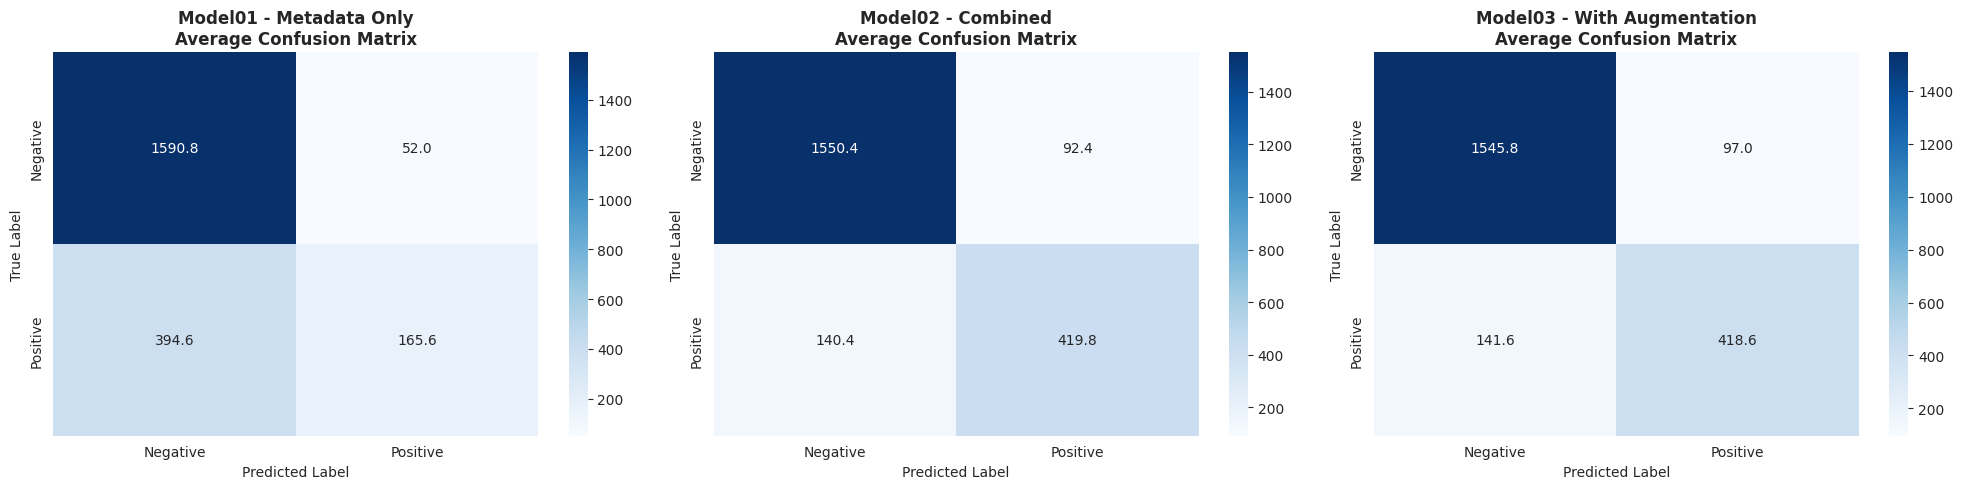

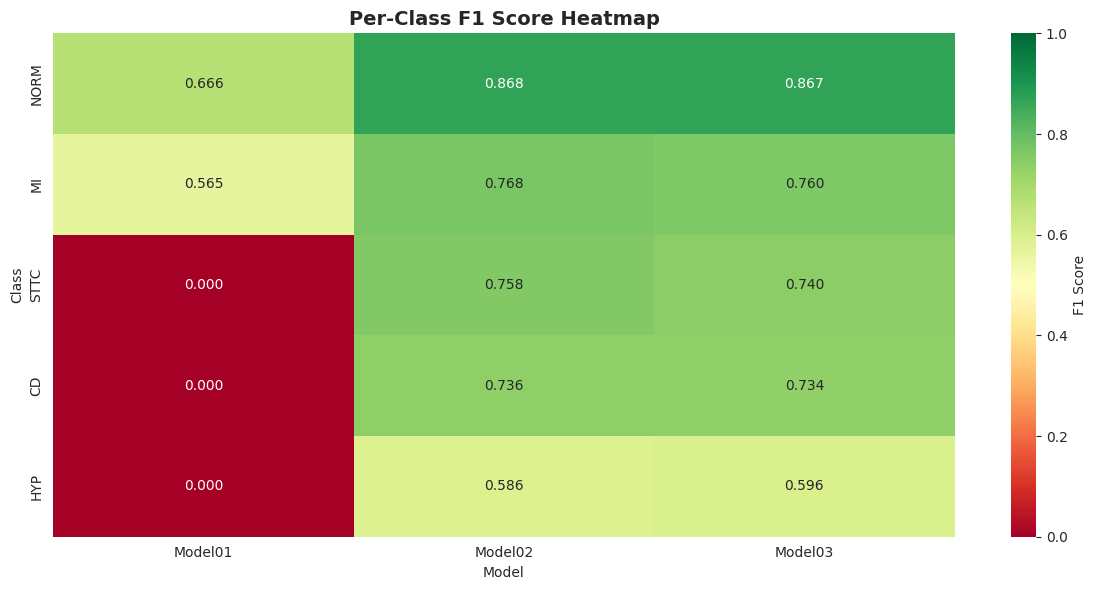

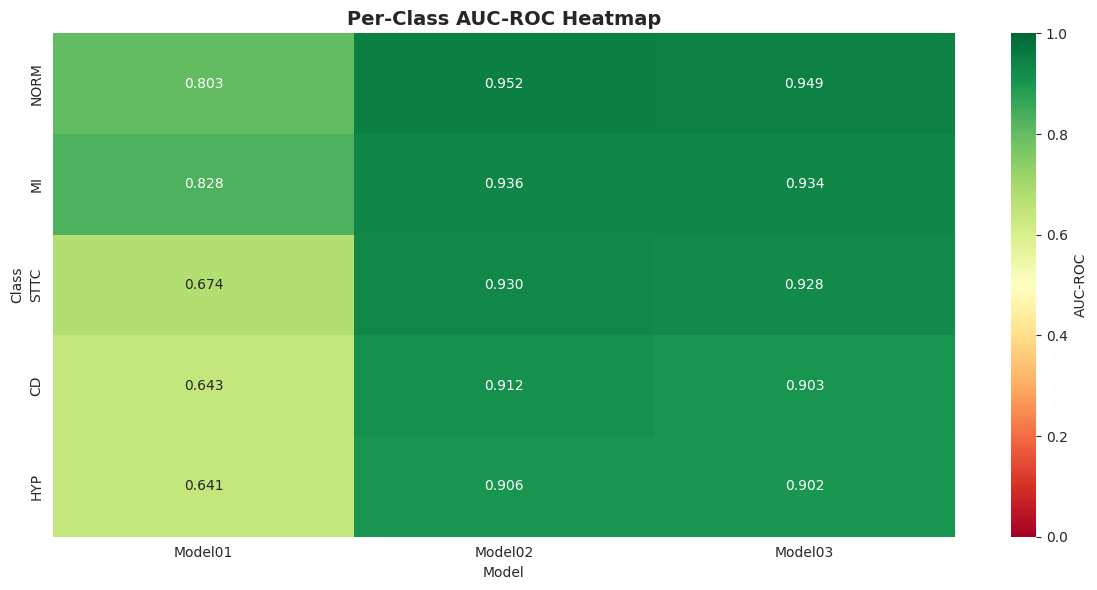


✓ Additional visualizations saved:
  - /kaggle/working/confusion_matrices.png
  - /kaggle/working/f1_heatmap.png
  - /kaggle/working/auc_heatmap.png


In [30]:
# ============================================================================
# ADDITIONAL VISUALIZATIONS - CONFUSION MATRICES & HEATMAPS
# ============================================================================

# Create confusion matrices for each model
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

models_data = [
    ('Model01 - Metadata Only', y_true_m1, (y_pred_m1 >= 0.5).astype(int)),
    ('Model02 - Combined', y_true_m2, (y_pred_m2 >= 0.5).astype(int)),
    ('Model03 - With Augmentation', y_true_m3, (y_pred_m3 >= 0.5).astype(int))
]

for idx, (model_name, y_true, y_pred_binary) in enumerate(models_data):
    # Calculate average confusion matrix across all classes
    cm_sum = np.zeros((2, 2))
    for i in range(len(SUPERCLASSES)):
        cm = confusion_matrix(y_true[:, i], y_pred_binary[:, i])
        if cm.shape == (2, 2):
            cm_sum += cm
    
    cm_avg = cm_sum / len(SUPERCLASSES)
    
    # Plot heatmap
    sns.heatmap(cm_avg, annot=True, fmt='.1f', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'{model_name}\nAverage Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(KAGGLE_WORKING, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

# Create heatmap of per-class F1 scores
fig, ax = plt.subplots(figsize=(12, 6))

f1_heatmap_data = []
for class_name in SUPERCLASSES:
    f1_heatmap_data.append([
        class_metrics_m1[class_name]['f1'],
        class_metrics_m2[class_name]['f1'],
        class_metrics_m3[class_name]['f1']
    ])

f1_heatmap_df = pd.DataFrame(f1_heatmap_data, 
                              index=SUPERCLASSES, 
                              columns=['Model01', 'Model02', 'Model03'])

sns.heatmap(f1_heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, center=0.5, ax=ax, cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Class F1 Score Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Class')

plt.tight_layout()
plt.savefig(os.path.join(KAGGLE_WORKING, 'f1_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# Create heatmap of per-class AUC-ROC scores
fig, ax = plt.subplots(figsize=(12, 6))

auc_heatmap_data = []
for class_name in SUPERCLASSES:
    auc_heatmap_data.append([
        class_metrics_m1[class_name]['auc'],
        class_metrics_m2[class_name]['auc'],
        class_metrics_m3[class_name]['auc']
    ])

auc_heatmap_df = pd.DataFrame(auc_heatmap_data, 
                              index=SUPERCLASSES, 
                              columns=['Model01', 'Model02', 'Model03'])

sns.heatmap(auc_heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, center=0.5, ax=ax, cbar_kws={'label': 'AUC-ROC'})
ax.set_title('Per-Class AUC-ROC Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Class')

plt.tight_layout()
plt.savefig(os.path.join(KAGGLE_WORKING, 'auc_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Additional visualizations saved:")
print(f"  - {os.path.join(KAGGLE_WORKING, 'confusion_matrices.png')}")
print(f"  - {os.path.join(KAGGLE_WORKING, 'f1_heatmap.png')}")
print(f"  - {os.path.join(KAGGLE_WORKING, 'auc_heatmap.png')}")


## Summary

The evaluation cells above provide:

### 📊 Visualizations Generated:
1. **Overall Metrics Comparison** - Bar chart comparing accuracy, precision, recall, F1, and AUC-ROC
2. **Per-Class Performance** - Bar charts for F1 score, AUC-ROC, precision, and recall by class
3. **ROC Curves** - ROC curves for all classes in the best model
4. **Confusion Matrices** - Average confusion matrices for each model
5. **Heatmaps** - Per-class F1 and AUC-ROC heatmaps for easy comparison

### 📈 Metrics Tables:
- **Overall Comparison Table** - Summary of all macro/micro metrics
- **Per-Class Tables** - Detailed metrics for each diagnostic class
- **Best Model Summary** - Which model performs best for each metric

### 💾 Saved Files:
All visualizations and tables are saved to `/kaggle/working/`:
- `models_comparison.png` - Main comparison visualization
- `confusion_matrices.png` - Confusion matrices
- `f1_heatmap.png` - F1 score heatmap
- `auc_heatmap.png` - AUC-ROC heatmap
- `overall_metrics_comparison.csv` - Overall metrics table
- `per_class_metrics_comparison.csv` - Per-class metrics table

You can download these files from the Kaggle output panel!
